In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

In [2]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


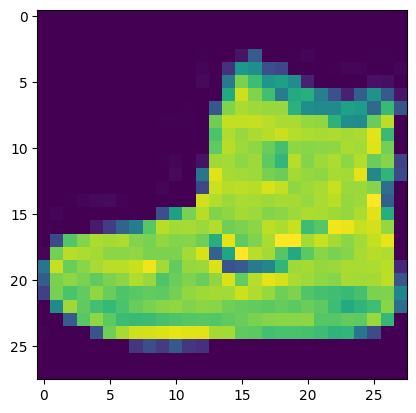

In [4]:
plt.imshow(X_train[0])
plt.show()

In [5]:
class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

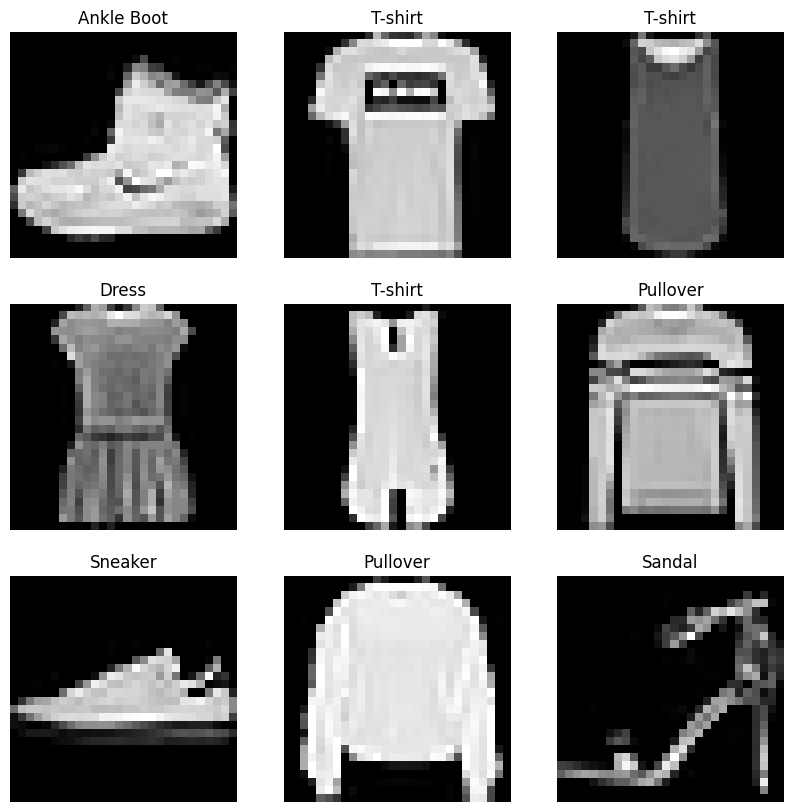

In [6]:
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.show()

In [7]:
X_train = X_train / 255.0
X_test = X_test / 255.0


In [8]:
print(X_train[0].max())

1.0


In [9]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1783083786.816224      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783083786.819721      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
  75/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5350 - loss: 1.3744

I0000 00:00:1783083790.662020      70 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8197 - loss: 0.5140 - val_accuracy: 0.8436 - val_loss: 0.4272
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8604 - loss: 0.3835 - val_accuracy: 0.8662 - val_loss: 0.3779
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8746 - loss: 0.3437 - val_accuracy: 0.8717 - val_loss: 0.3524
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8819 - loss: 0.3190 - val_accuracy: 0.8783 - val_loss: 0.3366
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8884 - loss: 0.2993 - val_accuracy: 0.8800 - val_loss: 0.3274
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8941 - loss: 0.2846 - val_accuracy: 0.8823 - val_loss: 0.3279
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9000 - loss: 0.2688 - val_accuracy: 0.8817 - val_loss: 0.3352
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9043 - loss: 0.2590 - val_accurac

In [12]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

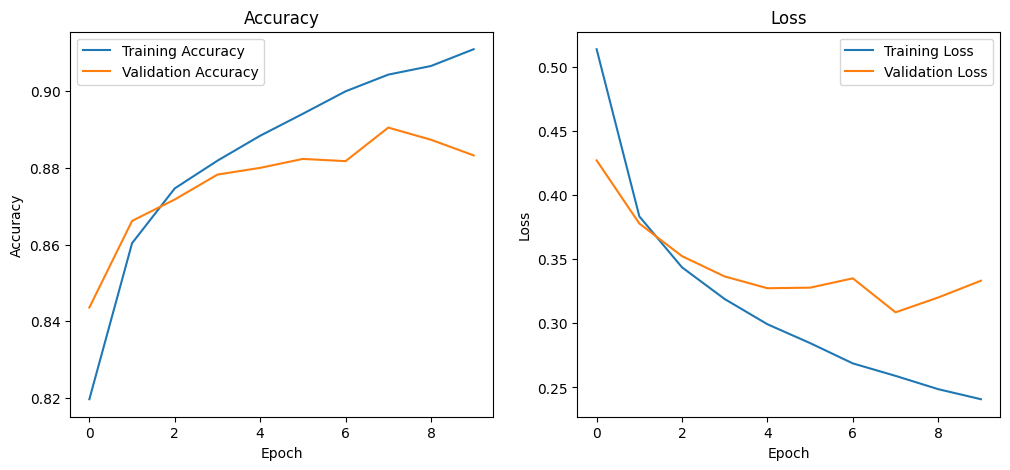

In [13]:
plt.figure(figsize=(12,5))

# Accuracy Graph
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss Graph
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [14]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(test_loss)
print(test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8756 - loss: 0.3626
0.36260125041007996
0.8755999803543091


In [15]:
prediction = model.predict(X_test[20].reshape(1,28,28))

predicted_class = np.argmax(prediction)

print("Predicted:", class_names[predicted_class])
print("Actual:", class_names[y_test[20]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
Predicted: Pullover
Actual: Pullover


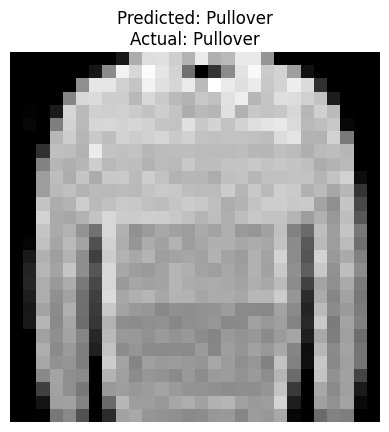

In [16]:
plt.imshow(X_test[20], cmap='gray')
plt.title(f"Predicted: {class_names[predicted_class]}\nActual: {class_names[y_test[20]]}")
plt.axis("off")
plt.show()

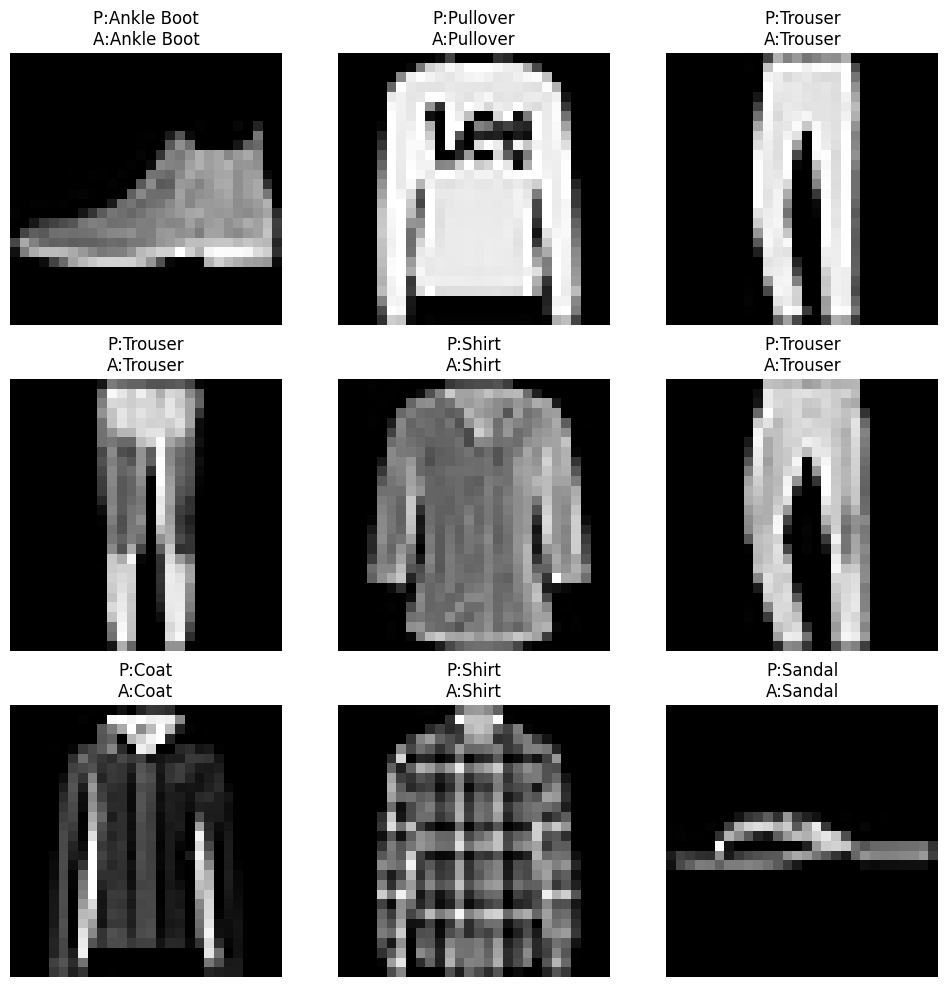

In [17]:
plt.figure(figsize=(12,12))

for i in range(9):

    plt.subplot(3,3,i+1)

    prediction = model.predict(X_test[i].reshape(1,28,28), verbose=0)

    predicted = np.argmax(prediction)

    plt.imshow(X_test[i], cmap='gray')

    plt.title(f"P:{class_names[predicted]}\nA:{class_names[y_test[i]]}")

    plt.axis("off")

plt.show()

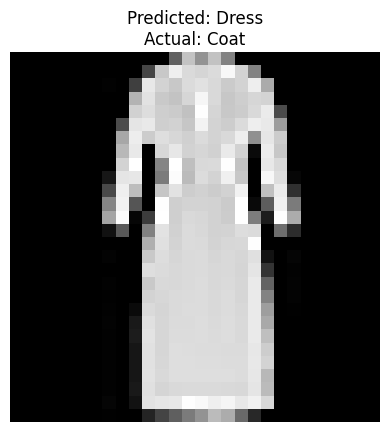

In [18]:
import random

index = random.randint(0, len(X_test)-1)

prediction = model.predict(X_test[index].reshape(1,28,28), verbose=0)

predicted = np.argmax(prediction)

plt.imshow(X_test[index], cmap='gray')

plt.title(f"Predicted: {class_names[predicted]}\nActual: {class_names[y_test[index]]}")

plt.axis("off")

plt.show()

In [19]:
prediction = model.predict(X_test[0].reshape(1,28,28), verbose=0)

for i in range(10):
    print(f"{class_names[i]} : {prediction[0][i]:.4f}")

T-shirt : 0.0000
Trouser : 0.0000
Pullover : 0.0000
Dress : 0.0000
Coat : 0.0000
Sandal : 0.0210
Shirt : 0.0000
Sneaker : 0.0572
Bag : 0.0000
Ankle Boot : 0.9218
